In [17]:
import matplotlib.pyplot as plt
import astricaltools as at
import numpy as np
import pandas as pd
import scipy.stats as sc
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.table import vstack, Table
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle

In [18]:
#===================== ESTRAGGO DATAFRAME BUONO ================================
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_201023_004_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        ntel= data["NTRIGTEL"]
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
            #creo il dataframe
        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "num_tel": ntel,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp),
            })

        dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted= df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()



astri_001_43_009_00002_R_201023_004_0201_SEB.lv0
astri_002_43_009_00002_R_201023_004_0201_SEB.lv0
astri_003_43_009_00002_R_201023_004_0201_SEB.lv0
astri_004_43_009_00002_R_201023_004_0201_SEB.lv0
astri_005_43_009_00002_R_201023_004_0201_SEB.lv0
astri_006_43_009_00002_R_201023_004_0201_SEB.lv0
astri_007_43_009_00002_R_201023_004_0201_SEB.lv0
astri_008_43_009_00002_R_201023_004_0201_SEB.lv0
astri_009_43_009_00002_R_201023_004_0201_SEB.lv0


In [19]:
# ======================= FUNZIONI GEOMETRICHE =======================
def intersection(p1, d1, p2, d2, eps_ang=1e-1, eps_det=1e-6):
    """
    p1, p2 = punti (2,)
    d1, d2 = direzioni (2,)
    """

    # --- controllo quasi-parallelismo ---
    det_dir = d1[0]*d2[1] - d1[1]*d2[0]
    if abs(det_dir) < eps_ang:        # <<< taglio fisico
        return None

    A = np.array([d1, -d2]).T
    b = p2 - p1

    detA = np.linalg.det(A)
    if abs(detA) < eps_det:           # <<< sicurezza numerica
        return None

    t = np.linalg.solve(A, b)[0]
    return p1 + t * d1
def d_punto_retta(P, p0, d):
    norm_d = np.linalg.norm(d)
    if norm_d == 0:
        return np.nan
    d_unit = d / norm_d
    v = P - p0
    return abs(v[0] * d_unit[1] - v[1] * d_unit[0])
def d_punto_retta_vec(P, p0, d):
    """
    distanza di N rette da un punto
    """
    norm_d = np.linalg.norm(d, axis=1)
    mask = norm_d > 0
    d_unit = np.zeros_like(d)
    d_unit[mask] = d[mask] / norm_d[mask, None]
    v = P - p0
    return np.abs(v[:, 0] * d_unit[:, 1] - v[:, 1] * d_unit[:, 0])

In [20]:
#============================ ESTRAZIONE RETTE ==========================
def principal_axis(cov):
    l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
        ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
    l2 = (cov[0,0] + cov[1,1])/2 - np.sqrt(
        ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)  # <-- ASSE MINORE
    theta = np.arctan2(l1 - cov[0,0], cov[0,1])
    return l1, l2, theta  # <-- RESTITUISCI ANCHE l2

#raccolgo i dati delle rette divisi per ogni (event,mcrun)
df_all_sorted=df_all_sorted[df_all_sorted["shape"]>5.16e6]
df_all_sorted=df_all_sorted[df_all_sorted["num_tel"]>=3]

xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

#rette_hg=[]
#rette_lg=[]
results = []
idx=0
for (event, mcrun), df_evt in df_all_sorted.groupby(["EVENT", "MCRUN"]):
    idx=idx+1
    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        n_pixels = np.sum(pxmask) 
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        

        l1_hg, l2_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, l2_lg,theta_lg = principal_axis(cov_lg)

        results.append({
            "revent": idx,
            "event": event,
            "mcrun": mcrun,
            "n_pixels": n_pixels,
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "l2":l2_hg,
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "l2":l2_lg,
                "tel": itel
            }
        })
#===========

In [21]:
#============================ ESTRAZIONE INTERSEZIONI ================================
# ======================= CALCOLO INTERSEZIONI =======================
inters_hg = []
inters_lg = []
dfR = pd.DataFrame(results)
for (event, mcrun), df_evt in dfR.groupby(["event", "mcrun"]):

    rette_hg = df_evt["HG"].values
    rette_lg = df_evt["LG"].values

    # ---------- HG ----------
    for i in range(len(rette_hg)):
        for j in range(i+1, len(rette_hg)):

            if rette_hg[i]["tel"] == rette_hg[j]["tel"]:
                continue

            d1 = rette_hg[i]["d"]
            d2 = rette_hg[j]["d"]

            P = intersection(rette_hg[i]["p0"], d1,rette_hg[j]["p0"], d2)

            if P is None:
                continue

            inters_hg.append({
                "event": event,
                "mcrun": mcrun,
                "P": P,
                "pair": (i, j)
            })

    # ---------- LG ----------
    for i in range(len(rette_lg)):
        for j in range(i+1, len(rette_lg)):

            if rette_lg[i]["tel"] == rette_lg[j]["tel"]:
                continue

            d1 = rette_lg[i]["d"]
            d2 = rette_lg[j]["d"]

            P = intersection(
                rette_lg[i]["p0"], d1,
                rette_lg[j]["p0"], d2
            )

            if P is None:
                continue

            inters_lg.append({
                "event": event,
                "mcrun": mcrun,
                "P": P,
                "pair": (i, j)
            })
df_int_hg = pd.DataFrame(inters_hg)
df_int_lg = pd.DataFrame(inters_lg)

In [22]:
#=========================== CLUSTERING ===================================
from sklearn.cluster import DBSCAN

epsilon = 295
min_samples = 1
revent_map = {}
revent_counter = 0
# ======================= HG =======================
dist_hg = []
delta_hg = []
for (event, mcrun), df_evt in df_int_hg.groupby(["event", "mcrun"]):
    # -------- REVENT --------
    if (event, mcrun) not in revent_map:
        revent_map[(event, mcrun)] = revent_counter
        revent_counter += 1
    revent = revent_map[(event, mcrun)]
    # ------------------------

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR.loc[
        (dfR["event"] == event) & (dfR["mcrun"] == mcrun),
        "HG"
    ]

    p0  = np.array([r["p0"]  for r in dfR_evt])
    d   = np.array([r["d"]   for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    for lab in cl_labels:

        mask = labels == lab
        Pcl  = P[mask]
        dfP  = df_evt.loc[mask]

        # ---------- pesi angolari (VETTORIALI) ----------
        pairs = np.array(dfP["pair"].tolist())      # (N,2)
        d1 = d[pairs[:, 0]]
        d2 = d[pairs[:, 1]]
        
        w = (d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0])**2   # sin^2(theta)
        pairs = np.array(dfP["pair"].tolist())      # (N,2)
        d1 = d[pairs[:, 0]]
        d2 = d[pairs[:, 1]]

        det = d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0]

        mask = np.abs(det) >= 1e-1    # TAGLIO NUMERICO

        if not np.any(mask):
            continue

        w   = det[mask]**2
        Pcl = Pcl[mask]
        # ---------- stimatori ----------
        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        # ---------- diagnostica ----------
        delta_hg.append(np.linalg.norm(P_weight - P_simple))

        # ---------- distanze ----------
        dist_w = d_punto_retta_vec(P_weight, p0, d)
        dist_m = d_punto_retta_vec(P_median, p0, d)
        dist_s = d_punto_retta_vec(P_simple, p0, d)
        for t, ds, dw, dm in zip(tel, dist_s, dist_w, dist_m):
            dist_hg.append({
                "revent": revent, 
                "event": event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_simple": ds,
                "d_weight": dw,
                "d_median": dm
            })
                

df_dist_hg = pd.DataFrame(dist_hg)
# ======================= LG =======================
dist_lg = []
delta_lg = []

for (event, mcrun), df_evt in df_int_lg.groupby(["event", "mcrun"]):
    # -------- REVENT --------
    if (event, mcrun) not in revent_map:
        revent_map[(event, mcrun)] = revent_counter
        revent_counter += 1
    revent = revent_map[(event, mcrun)]
    # ------------------------
    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR.loc[
        (dfR["event"] == event) & (dfR["mcrun"] == mcrun),
        "LG"
    ]

    p0  = np.array([r["p0"]  for r in dfR_evt])
    d   = np.array([r["d"]   for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])

    for lab in cl_labels:

        mask = labels == lab
        Pcl  = P[mask]
        dfP  = df_evt.loc[mask]

        pairs = np.array(dfP["pair"].tolist())
        d1 = d[pairs[:, 0]]
        d2 = d[pairs[:, 1]]

        w = (d1[:, 0]*d2[:, 1] - d1[:, 1]*d2[:, 0])**2

        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        delta_lg.append(np.linalg.norm(P_weight - P_simple))

        dist_w = d_punto_retta_vec(P_weight, p0, d)
        dist_m = d_punto_retta_vec(P_median, p0, d)
        dist_s = d_punto_retta_vec(P_simple, p0, d)
        for t, ds, dw, dm in zip(tel, dist_s, dist_w, dist_m):
            dist_lg.append({
                "revent": revent,
                "event": event,
                "mcrun": mcrun,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_simple": ds,
                "d_weight": dw,
                "d_median": dm
            })

df_dist_lg = pd.DataFrame(dist_lg)

In [23]:
#=========================== FAKE EVENT ==================================
import random
#vediamo due eventi presi casualmente
groups = list(df_all_sorted.groupby(["EVENT", "MCRUN"]))
random.shuffle(groups)
groups_A = groups[:len(groups)//2]
groups_B = groups[len(groups)//2:len(groups)]
fake_events = []
fevent_counter = 0
for i, ((evtA, dfA), (evtB, dfB)) in enumerate(zip(groups_A, groups_B)):
    if len(dfA) < 3 or len(dfB) < 3:
        continue

    #prendi almeno 3 telescopi da A e non più di quelli disponibili
    nA = max(3, len(dfA) // 2)
    nA = min(nA, len(dfA))
    partA = dfA.sample(n=nA, replace=False)

    #prendi almeno 3 telescopi da B e non più di quelli disponibili
    nB = max(3, len(dfB) // 2)
    nB = min(nB, len(dfB))
    partB = dfB.sample(n=nB, replace=False)

    # unione -> evento fittizio
    df_fake = pd.concat([partA, partB], ignore_index=True)
  
  
    # etichetta evento fittizio con contatore progressivo
    df_fake["FAKE_EVENT"] = fevent_counter
    fevent_counter += 1
    
    fake_events.append(df_fake)
#dataframe con tutti eventi fittizi
df_fake_all = pd.concat(fake_events, ignore_index=True)
df_fake_all.columns

Index(['TIME_NS', 'TIME_S', 'TIME_ABS', 'EVENT', 'MCRUN', 'TEL_ID', 'num_tel',
       'HG', 'LG', 'TTP', 'shape', 'FAKE_EVENT'],
      dtype='object')

In [24]:

taglio=0.1

xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)
#======================================== RETTE ===========================================================
#rette_hg=[]
#rette_lg=[]
results_f = []
for fevent, df_evt in df_fake_all.groupby(["FAKE_EVENT"]):

    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        n_pixels = np.sum(pxmask)
        if  np.sum(pxmask) == 0:
            continue
        # SIGMA-CLIPPING
    
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)
        # autovalori + direzione
        l1_hg, l2_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, l2_lg, theta_lg = principal_axis(cov_lg)
        
        results_f.append({
            "event": row["EVENT"],       
            "mcrun": row["MCRUN"],  
            "fevent": int(fevent[0]),
            "n_pixels": n_pixels,  
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "l2": l2_hg,  
                "tel": itel
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "l2": l2_lg,  
                "tel": itel
            }
        })        
dfR_f = pd.DataFrame(results_f)
# ======================= CALCOLO INTERSEZIONI =======================
inters_hg_f = []
inters_lg_f = []

  # results_f deve avere 'event', 'mcrun', 'fevent', 'HG', 'LG'

for fevent, df_evt in dfR_f.groupby("fevent"):

    rette_hg = df_evt["HG"].values
    rette_lg = df_evt["LG"].values
    events = df_evt["event"].values       # array degli eventi originali
    mcruns = df_evt["mcrun"].values       # array dei mcrun originali

    # ---------- HG ----------
    for i in range(len(rette_hg)):
        for j in range(i+1, len(rette_hg)):

            # ignora se stesso telescopio
            if rette_hg[i]["tel"] == rette_hg[j]["tel"]:
                continue

            d1 = rette_hg[i]["d"]
            d2 = rette_hg[j]["d"]
            ###########################################################################################verificare sto sen(theta)
            # ignora rette quasi parallele ########################################################################################################
            if abs(d1[0]*d2[1] - d1[1]*d2[0]) < taglio:
                continue

            # ignora se stesso evento reale
            #if (df_evt.iloc[i]["event"] == df_evt.iloc[j]["event"]) and (df_evt.iloc[i]["mcrun"] == df_evt.iloc[j]["mcrun"]):
                #continue

            #evt_i = (df_evt.iloc[i]["mcrun"], df_evt.iloc[i]["event"])
            #evt_j = (df_evt.iloc[j]["mcrun"], df_evt.iloc[j]["event"])
            #if evt_i >= evt_j:
                #continue
            P = intersection(rette_hg[i]["p0"], d1, rette_hg[j]["p0"], d2)
            if P is None:
                continue

            inters_hg_f.append({
                "fevent": fevent,
                "P": P,
                "pair": (i, j),
                "d1": d1,
                "d2": d2,
                #"p01":rette_hg[i]["p0"],
                #"p02":rette_hg[j]["p0"],
                "event_i": events[i],   # evento originale della retta i
                "mcrun_i": mcruns[i],   # mcrun originale della retta i
                "event_j": events[j],   # evento originale della retta j
                "mcrun_j": mcruns[j],   # mcrun originale della retta j
                "tel_i": rette_hg[i]["tel"],
                "tel_j": rette_hg[j]["tel"]
            })

    # ---------- LG ----------
    for i in range(len(rette_lg)):
        for j in range(i+1, len(rette_lg)):

            # ignora se stesso telescopio
            if rette_lg[i]["tel"] == rette_lg[j]["tel"]:
                continue

            d1 = rette_lg[i]["d"]
            d2 = rette_lg[j]["d"]

            # ignora rette quasi parallele
            if abs(d1[0]*d2[1] - d1[1]*d2[0]) < taglio:
                continue
             # ignora se stesso evento reale
            #if (df_evt.iloc[i]["event"] == df_evt.iloc[j]["event"]) and (df_evt.iloc[i]["mcrun"] == df_evt.iloc[j]["mcrun"]):
                #continue

            P = intersection(rette_lg[i]["p0"], d1, rette_lg[j]["p0"], d2)
            if P is None:
                continue
            # per i fevent
            
            inters_lg_f.append({
                "fevent": fevent,
                "P": P,
                "pair": (i, j),
                "d1": d1,
                "d2": d2,
                #"p01":rette_lg[i]["p0"],
                #"p02":rette_lg[j]["p0"],
                "event_i": events[i],
                "mcrun_i": mcruns[i],
                "event_j": events[j],
                "mcrun_j": mcruns[j],
                "tel_i": rette_lg[i]["tel"],
                "tel_j": rette_lg[j]["tel"]
            })

# dataframe finali
df_int_hg_f = pd.DataFrame(inters_hg_f)
df_int_lg_f = pd.DataFrame(inters_lg_f)

#print(df_int_hg_f[["fevent","mcrun_j","event_j","d1"]].head(40))
#print(dfR_f["fevent"].head(10))
print(df_int_hg_f.columns)





Index(['fevent', 'P', 'pair', 'd1', 'd2', 'event_i', 'mcrun_i', 'event_j',
       'mcrun_j', 'tel_i', 'tel_j'],
      dtype='object')


In [25]:
from sklearn.cluster import DBSCAN


epsilon = 295
min_samples = 1

# ======================= HG FAKE =======================
dist_hg_f = []

for fevent, df_evt in df_int_hg_f.groupby("fevent"):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    # rette dell'evento falso
    dfR_evt = dfR_f.loc[dfR_f["fevent"] == fevent, "HG"]   
    p0  = np.vstack([r["p0"] for r in dfR_evt])
    d   = np.vstack([r["d"]  for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])
    evt_arr = dfR_f.loc[dfR_f["fevent"] == fevent, "event"].values
    mc_arr  = dfR_f.loc[dfR_f["fevent"] == fevent, "mcrun"].values

    for lab in cl_labels:
        Pcl = P[labels == lab]
        dfP = df_evt[labels == lab]

        # ---------- calcolo pesi angolari ----------
        w = np.array([
            (row["d1"][0]*row["d2"][1] - row["d1"][1]*row["d2"][0])**2
            for _, row in dfP.iterrows()
        ])

        # ---------- stimatori ----------
        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        # ---------- distanze ----------
        dist_mean_simple   = d_punto_retta_vec(P_simple, p0, d)
        dist_mean_weighted = d_punto_retta_vec(P_weight, p0, d)
        dist_median        = d_punto_retta_vec(P_median, p0, d)

        for t, dm_s, dm_w, dmed, evt, mc in zip(
            tel, dist_mean_simple, dist_mean_weighted, dist_median, evt_arr, mc_arr
        ):
            dist_hg_f.append({
                "fevent": fevent,
                "event": evt,
                "mcrun": mc,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_mean_simple": dm_s,
                "d_weight": dm_w,
                "d_median": dmed
            })

df_dist_hg_f = pd.DataFrame(dist_hg_f)

# ======================= LG FAKE =======================
dist_lg_f = []

for fevent, df_evt in df_int_lg_f.groupby("fevent"):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    dfR_evt = dfR_f.loc[dfR_f["fevent"] == fevent, "LG"]   
    p0  = np.vstack([r["p0"] for r in dfR_evt])
    d   = np.vstack([r["d"]  for r in dfR_evt])
    tel = np.array([r["tel"] for r in dfR_evt])
    evt_arr = dfR_f.loc[dfR_f["fevent"] == fevent, "event"].values
    mc_arr  = dfR_f.loc[dfR_f["fevent"] == fevent, "mcrun"].values

    for lab in cl_labels:
        Pcl = P[labels == lab]
        dfP = df_evt[labels == lab]

        w = np.array([
            (row["d1"][0]*row["d2"][1] - row["d1"][1]*row["d2"][0])**2
            for _, row in dfP.iterrows()
        ])

        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        dist_mean_simple   = d_punto_retta_vec(P_simple, p0, d)
        dist_mean_weighted = d_punto_retta_vec(P_weight, p0, d)
        dist_median        = d_punto_retta_vec(P_median, p0, d)

        for t, dm_s, dm_w, dmed, evt, mc in zip(
            tel, dist_mean_simple, dist_mean_weighted, dist_median, evt_arr, mc_arr
        ):
            dist_lg_f.append({
                "fevent": fevent,
                "event": evt,
                "mcrun": mc,
                "cluster": lab,
                "tel": t,
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_mean_simple": dm_s,
                "d_weight": dm_w,
                "d_median": dmed
            })

df_dist_lg_f = pd.DataFrame(dist_lg_f)

# ======================= check =======================
print(f"Distanze HG fake: {len(df_dist_hg_f)}")
print(f"Distanze LG fake: {len(df_dist_lg_f)}")

# ======================= SUMMARY =======================
print("\n" + "="*60)
print("FAKE EVENTS - SUMMARY")
print("="*60)

print(f"Rette HG fake: {len(results_f)}")
print(f"Intersezioni HG fake: {len(df_int_hg_f)}")
print(f"Intersezioni LG fake: {len(df_int_lg_f)}")
print(f"Distanze HG fake: {len(df_dist_hg_f)}")
print(f"Distanze LG fake: {len(df_dist_lg_f)}")
print("="*60)

Distanze HG fake: 2362
Distanze LG fake: 2393

FAKE EVENTS - SUMMARY
Rette HG fake: 1442
Intersezioni HG fake: 3379
Intersezioni LG fake: 3390
Distanze HG fake: 2362
Distanze LG fake: 2393



MASSIMI DELLE DISTRIBUZIONI A 1 CLUSTER

HG Mean:   28.329
HG Median: 54.606
LG Mean:   30.273
LG Median: 63.353

TAGLIO CONSERVATIVO (max di tutti): 63.353


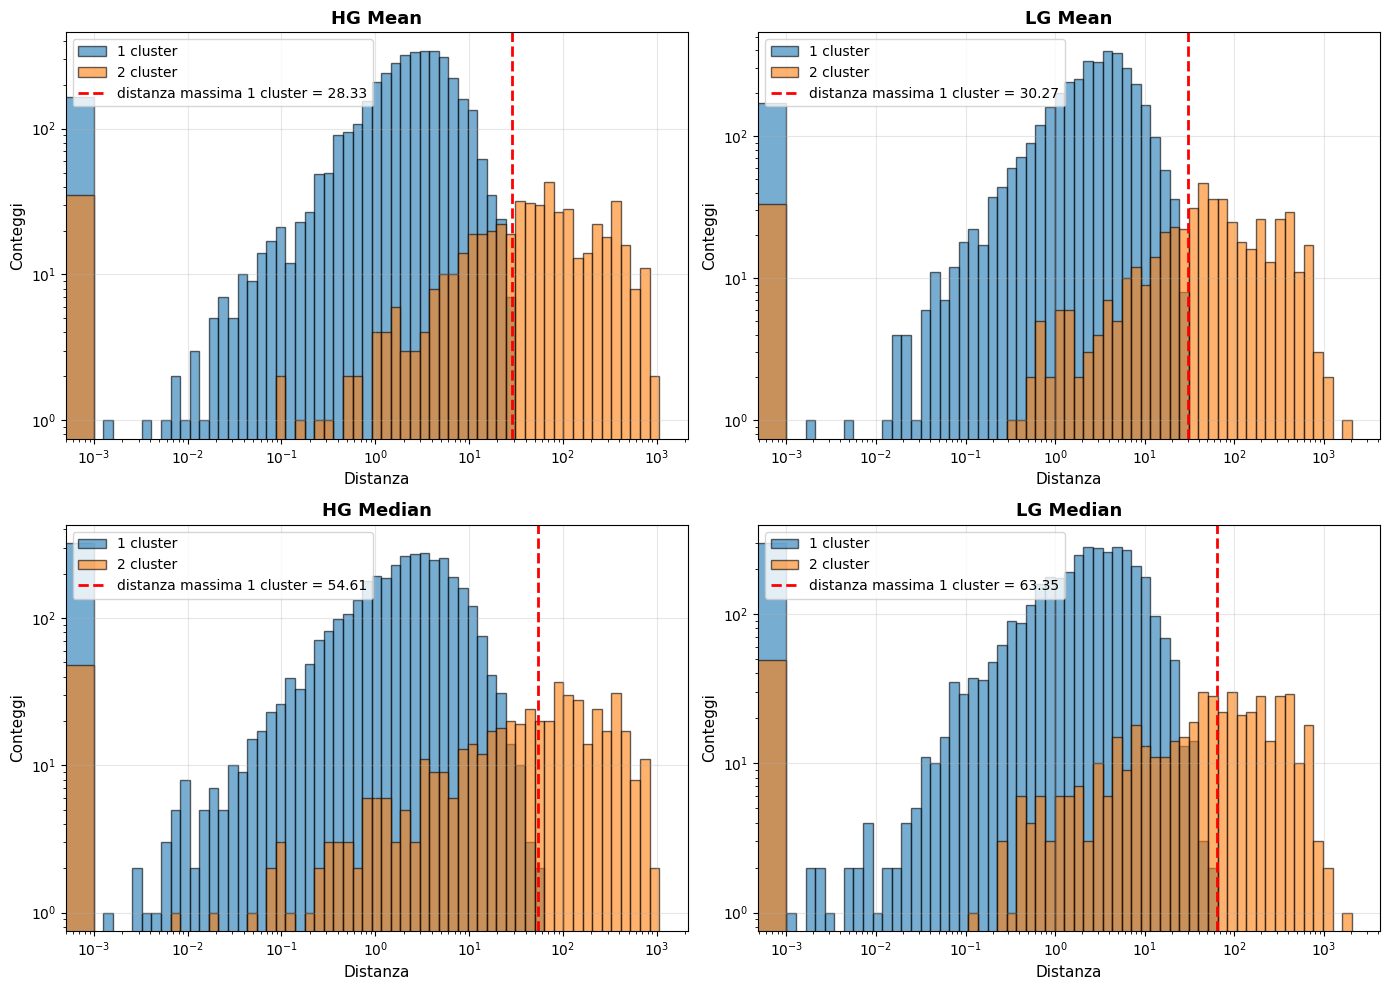


VERIFICA: quanti eventi 2c includi con questi tagli?
HG Mean      (taglio= 28.33):  199/ 536 eventi 2c inclusi ( 37.1%)
HG Median    (taglio= 54.61):  282/ 531 eventi 2c inclusi ( 53.1%)
LG Mean      (taglio= 30.27):  187/ 525 eventi 2c inclusi ( 35.6%)
LG Median    (taglio= 63.35):  291/ 522 eventi 2c inclusi ( 55.7%)


In [26]:
zero_threshold = 0.001
n_bins = 60
def smart_bins(data, n_bins=n_bins, zero_threshold=zero_threshold):
    """Crea bins logaritmici + bin speciale per valori ~0"""
    bin_zero = [0, zero_threshold]
    log_bins = np.logspace(np.log10(zero_threshold), np.log10(data.max()*1.1), n_bins)
    return np.unique(np.concatenate([bin_zero, log_bins]))

# ===================== SELEZIONE EVENTI =====================
# -------------------- Eventi con 1 cluster --------------------
eventi_cluster_hg_1 = df_dist_hg.groupby(["revent"])["cluster"].nunique()
eventi_validi_hg_1 = eventi_cluster_hg_1[eventi_cluster_hg_1 == 1].index
df_sel_hg_1 = df_dist_hg.set_index(["revent"]).loc[eventi_validi_hg_1].reset_index()

eventi_cluster_lg_1 = df_dist_lg.groupby(["revent"])["cluster"].nunique()
eventi_validi_lg_1 = eventi_cluster_lg_1[eventi_cluster_lg_1 == 1].index
df_sel_lg_1 = df_dist_lg.set_index(["revent"]).loc[eventi_validi_lg_1].reset_index()

eventi_cluster_hg_f_1 = df_dist_hg_f.groupby(["fevent"])["cluster"].nunique()
eventi_validi_hg_f_1 = eventi_cluster_hg_f_1[eventi_cluster_hg_f_1 == 1].index
df_sel_hg_f_1 = df_dist_hg_f.set_index(["fevent"]).loc[eventi_validi_hg_f_1].reset_index()

eventi_cluster_lg_f_1 = df_dist_lg_f.groupby(["fevent"])["cluster"].nunique()
eventi_validi_lg_f_1 = eventi_cluster_lg_f_1[eventi_cluster_lg_f_1 == 1].index
df_sel_lg_f_1 = df_dist_lg_f.set_index(["fevent"]).loc[eventi_validi_lg_f_1].reset_index()


# -------------------- Eventi con 2 cluster --------------------
eventi_cluster_hg_2 = df_dist_hg.groupby(["revent"])["cluster"].nunique()
eventi_validi_hg_2 = eventi_cluster_hg_2[eventi_cluster_hg_2 == 2].index
df_sel_hg_2 = df_dist_hg.set_index(["revent"]).loc[eventi_validi_hg_2].reset_index()

eventi_cluster_lg_2 = df_dist_lg.groupby(["revent"])["cluster"].nunique()
eventi_validi_lg_2 = eventi_cluster_lg_2[eventi_cluster_lg_2 == 2].index
df_sel_lg_2 = df_dist_lg.set_index(["revent"]).loc[eventi_validi_lg_2].reset_index()

eventi_cluster_hg_f_2 = df_dist_hg_f.groupby(["fevent"])["cluster"].nunique()
eventi_validi_hg_f_2 = eventi_cluster_hg_f_2[eventi_cluster_hg_f_2 == 2].index
df_sel_hg_f_2 = df_dist_hg_f.set_index(["fevent"]).loc[eventi_validi_hg_f_2].reset_index()

eventi_cluster_lg_f_2 = df_dist_lg_f.groupby(["fevent"])["cluster"].nunique()
eventi_validi_lg_f_2 = eventi_cluster_lg_f_2[eventi_cluster_lg_f_2 == 2].index
df_sel_lg_f_2 = df_dist_lg_f.set_index(["fevent"]).loc[eventi_validi_lg_f_2].reset_index()


# ===================== ESTRAZIONE DISTANZE =====================
d_mean_hg_1   = df_sel_hg_1["d_weight"].values
d_median_hg_1 = df_sel_hg_1["d_median"].values
d_mean_lg_1   = df_sel_lg_1["d_weight"].values
d_median_lg_1 = df_sel_lg_1["d_median"].values
d_mean_hg_f_1   = df_sel_hg_f_1["d_weight"].values
d_median_hg_f_1 = df_sel_hg_f_1["d_median"].values
d_mean_lg_f_1   = df_sel_lg_f_1["d_weight"].values
d_median_lg_f_1 = df_sel_lg_f_1["d_median"].values

d_mean_hg_2   = df_sel_hg_2["d_weight"].values
d_median_hg_2 = df_sel_hg_2["d_median"].values
d_mean_lg_2   = df_sel_lg_2["d_weight"].values
d_median_lg_2 = df_sel_lg_2["d_median"].values
d_mean_hg_f_2   = df_sel_hg_f_2["d_weight"].values
d_median_hg_f_2 = df_sel_hg_f_2["d_median"].values
d_mean_lg_f_2   = df_sel_lg_f_2["d_weight"].values
d_median_lg_f_2 = df_sel_lg_f_2["d_median"].values

# filtro valori validi (>0 e finiti)
datasets_1 = [d_mean_hg_1, d_median_hg_1, d_mean_lg_1, d_median_lg_1,
              d_mean_hg_f_1, d_median_hg_f_1, d_mean_lg_f_1, d_median_lg_f_1]
datasets_1 = [d[np.isfinite(d) & (d > 0)] for d in datasets_1]
d_mean_hg_1, d_median_hg_1, d_mean_lg_1, d_median_lg_1, \
d_mean_hg_f_1, d_median_hg_f_1, d_mean_lg_f_1, d_median_lg_f_1 = datasets_1

datasets_2 = [d_mean_hg_2, d_median_hg_2, d_mean_lg_2, d_median_lg_2,
              d_mean_hg_f_2, d_median_hg_f_2, d_mean_lg_f_2, d_median_lg_f_2]
datasets_2 = [d[np.isfinite(d) & (d > 0)] for d in datasets_2]
d_mean_hg_2, d_median_hg_2, d_mean_lg_2, d_median_lg_2, \
d_mean_hg_f_2, d_median_hg_f_2, d_mean_lg_f_2, d_median_lg_f_2 = datasets_2

# ===================== BINS COMUNI =====================
bins_mean_hg_1   = smart_bins(np.concatenate([d_mean_hg_1, d_mean_hg_f_1]))
bins_median_hg_1 = smart_bins(np.concatenate([d_median_hg_1, d_median_hg_f_1]))
bins_mean_lg_1   = smart_bins(np.concatenate([d_mean_lg_1, d_mean_lg_f_1]))
bins_median_lg_1 = smart_bins(np.concatenate([d_median_lg_1, d_median_lg_f_1]))

bins_mean_hg_2   = smart_bins(np.concatenate([d_mean_hg_2, d_mean_hg_f_2]))
bins_median_hg_2 = smart_bins(np.concatenate([d_median_hg_2, d_median_hg_f_2]))
bins_mean_lg_2   = smart_bins(np.concatenate([d_mean_lg_2, d_mean_lg_f_2]))
bins_median_lg_2 = smart_bins(np.concatenate([d_median_lg_2, d_median_lg_f_2]))

# ===================== CALCOLA I MASSIMI =====================
print("\n" + "="*60)
print("MASSIMI DELLE DISTRIBUZIONI A 1 CLUSTER")
print("="*60)

max_hg_mean = d_mean_hg_1.max()
max_hg_median = d_median_hg_1.max()
max_lg_mean = d_mean_lg_1.max()
max_lg_median = d_median_lg_1.max()

print(f"\nHG Mean:   {max_hg_mean:.3f}")
print(f"HG Median: {max_hg_median:.3f}")
print(f"LG Mean:   {max_lg_mean:.3f}")
print(f"LG Median: {max_lg_median:.3f}")

# Taglio unico conservativo (il più alto)
taglio_conservativo = max(max_hg_mean, max_hg_median, max_lg_mean, max_lg_median)
print(f"\nTAGLIO CONSERVATIVO (max di tutti): {taglio_conservativo:.3f}")

print("="*60)

# ===================== PLOT CON LINEA DI TAGLIO =====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets_info = [
    (d_mean_hg_1, d_mean_hg_f_2, max_hg_mean, "HG Mean", axes[0,0]),
    (d_median_hg_1, d_median_hg_f_2, max_hg_median, "HG Median", axes[1,0]),
    (d_mean_lg_1, d_mean_lg_f_2, max_lg_mean, "LG Mean", axes[0,1]),
    (d_median_lg_1, d_median_lg_f_2, max_lg_median, "LG Median", axes[1,1])
]

for d_1cluster, d_2cluster, max_val, title, ax in datasets_info:
    bins = smart_bins(np.concatenate([d_1cluster, d_2cluster]))
    
    ax.hist(d_1cluster, bins=bins, edgecolor='black', alpha=0.6, 
            label='1 cluster')
    ax.hist(d_2cluster, bins=bins, edgecolor='black', alpha=0.6, 
            label='2 cluster')
    
    # Linea verticale al massimo
    ax.axvline(max_val, color='red', linestyle='--', linewidth=2, 
               label=f'distanza massima 1 cluster = {max_val:.2f}')
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Distanza', fontsize=11)
    ax.set_ylabel('Conteggi', fontsize=11)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===================== VERIFICA =====================
print("\n" + "="*60)
print("VERIFICA: quanti eventi 2c includi con questi tagli?")
print("="*60)

for name, d_2cluster, max_val in [
    ("HG Mean", d_mean_hg_f_2, max_hg_mean),
    ("HG Median", d_median_hg_f_2, max_hg_median),
    ("LG Mean", d_mean_lg_f_2, max_lg_mean),
    ("LG Median", d_median_lg_f_2, max_lg_median)
]:
    n_inclusi = np.sum(d_2cluster <= max_val)
    perc_inclusi = n_inclusi / len(d_2cluster) * 100
    print(f"{name:12} (taglio={max_val:6.2f}): {n_inclusi:4d}/{len(d_2cluster):4d} eventi 2c inclusi ({perc_inclusi:5.1f}%)")

print("="*60)

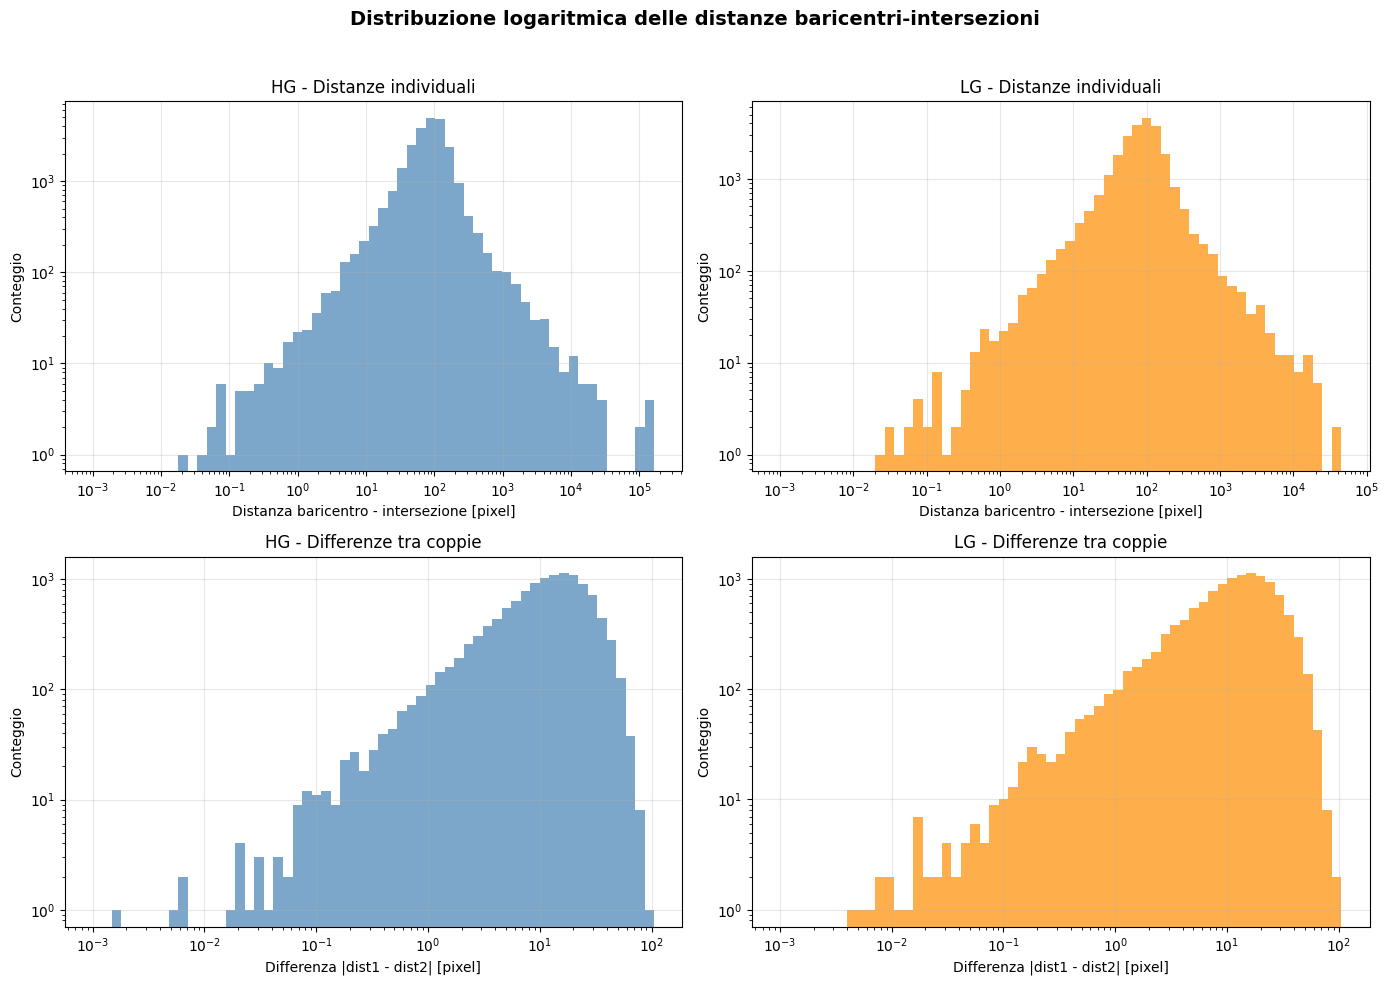


STATISTICHE DISTANZE BARICENTRI-INTERSEZIONI

HG - Distanze individuali:
  N. totale: 24346
  Media: 181.30 pixel
  Mediana: 86.57 pixel
  Max: 149620.65 pixel

HG - Differenze tra coppie:
  N. totale: 12173
  Media: 14.24 pixel
  Mediana: 11.58 pixel
  Max: 95.95 pixel

LG - Distanze individuali:
  N. totale: 24346
  Media: 158.07 pixel
  Mediana: 86.39 pixel
  Max: 40984.65 pixel

LG - Differenze tra coppie:
  N. totale: 12173
  Media: 14.47 pixel
  Mediana: 11.72 pixel
  Max: 96.14 pixel


In [27]:
###======================== DISTANZA CENTROIDE INTERSEZIONE =================================

dfR = pd.DataFrame(results)

# separiamo HG e LG in DataFrame più comodi
dfR_hg = pd.DataFrame([{
    "revent": r["revent"],
    "event": r["event"],
    "mcrun": r["mcrun"],
    "tel": r["HG"]["tel"],
    "p0": r["HG"]["p0"],
    "d": r["HG"]["d"]
} for r in results])

dfR_lg = pd.DataFrame([{
    "revent": r["revent"],
    "event": r["event"],
    "mcrun": r["mcrun"],
    "tel": r["LG"]["tel"],
    "p0": r["LG"]["p0"],
    "d": r["LG"]["d"]
} for r in results])

from itertools import combinations

def intersection_distances(df_evt):
    """
    df_evt: DataFrame di un singolo evento (revent)
    Restituisce:
    - distances: lista di tutte le distanze individuali baricentro-intersezione
    - diff_distances: lista delle differenze |dist1 - dist2| per ogni coppia
    """
    p0s = np.vstack(df_evt["p0"].values)
    ds   = np.vstack(df_evt["d"].values)
    distances = []
    diff_distances = []

    for (i, (p1, d1)), (j, (p2, d2)) in combinations(enumerate(zip(p0s, ds)), 2):
        # controllo quasi-parallelismo
        det = d1[0]*d2[1] - d1[1]*d2[0]
        if np.abs(det) < 1e-6:
            continue

        # calcolo intersezione
        A = np.array([d1, -d2]).T
        b = p2 - p1
        detA = np.linalg.det(A)
        if np.abs(detA) < 1e-6:
            continue
            
        t = np.linalg.solve(A, b)[0]
        P_inter = p1 + t*d1

        # distanza di ciascun baricentro dall'intersezione
        dist1 = np.linalg.norm(p1 - P_inter)
        dist2 = np.linalg.norm(p2 - P_inter)
        
        distances.append(dist1)
        distances.append(dist2)
        
        # differenza assoluta
        diff_distances.append(np.abs(dist1 - dist2))

    return distances, diff_distances

# Calcola per HG
distances_hg = []
diff_distances_hg = []
for revent, df_evt in dfR_hg.groupby("revent"):
    dists, diffs = intersection_distances(df_evt)
    distances_hg.extend(dists)
    diff_distances_hg.extend(diffs)

# Calcola per LG
distances_lg = []
diff_distances_lg = []
for revent, df_evt in dfR_lg.groupby("revent"):
    dists, diffs = intersection_distances(df_evt)
    distances_lg.extend(dists)
    diff_distances_lg.extend(diffs)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# HG - Distanze individuali
axes[0, 0].hist(distances_hg, bins=smart_bins(np.array(distances_hg)), color='steelblue', alpha=0.7)
axes[0, 0].set_xscale('log')
axes[0, 0].set_yscale('log')
axes[0, 0].set_xlabel("Distanza baricentro - intersezione [pixel]")
axes[0, 0].set_ylabel("Conteggio")
axes[0, 0].set_title("HG - Distanze individuali")
axes[0, 0].grid(True, alpha=0.3)

# LG - Distanze individuali
axes[0, 1].hist(distances_lg, bins=smart_bins(np.array(distances_lg)), color='darkorange', alpha=0.7)
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xlabel("Distanza baricentro - intersezione [pixel]")
axes[0, 1].set_ylabel("Conteggio")
axes[0, 1].set_title("LG - Distanze individuali")
axes[0, 1].grid(True, alpha=0.3)

# HG - Differenze
axes[1, 0].hist(diff_distances_hg, bins=smart_bins(np.array(diff_distances_hg)), color='steelblue', alpha=0.7)
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel("Differenza |dist1 - dist2| [pixel]")
axes[1, 0].set_ylabel("Conteggio")
axes[1, 0].set_title("HG - Differenze tra coppie")
axes[1, 0].grid(True, alpha=0.3)

# LG - Differenze
axes[1, 1].hist(diff_distances_lg, bins=smart_bins(np.array(diff_distances_lg)), color='darkorange', alpha=0.7)
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].set_xlabel("Differenza |dist1 - dist2| [pixel]")
axes[1, 1].set_ylabel("Conteggio")
axes[1, 1].set_title("LG - Differenze tra coppie")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("Distribuzione logaritmica delle distanze baricentri-intersezioni", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Statistiche
print("\n" + "="*60)
print("STATISTICHE DISTANZE BARICENTRI-INTERSEZIONI")
print("="*60)

print(f"\nHG - Distanze individuali:")
print(f"  N. totale: {len(distances_hg)}")
print(f"  Media: {np.mean(distances_hg):.2f} pixel")
print(f"  Mediana: {np.median(distances_hg):.2f} pixel")
print(f"  Max: {np.max(distances_hg):.2f} pixel")

print(f"\nHG - Differenze tra coppie:")
print(f"  N. totale: {len(diff_distances_hg)}")
print(f"  Media: {np.mean(diff_distances_hg):.2f} pixel")
print(f"  Mediana: {np.median(diff_distances_hg):.2f} pixel")
print(f"  Max: {np.max(diff_distances_hg):.2f} pixel")

print(f"\nLG - Distanze individuali:")
print(f"  N. totale: {len(distances_lg)}")
print(f"  Media: {np.mean(distances_lg):.2f} pixel")
print(f"  Mediana: {np.median(distances_lg):.2f} pixel")
print(f"  Max: {np.max(distances_lg):.2f} pixel")

print(f"\nLG - Differenze tra coppie:")
print(f"  N. totale: {len(diff_distances_lg)}")
print(f"  Media: {np.mean(diff_distances_lg):.2f} pixel")
print(f"  Mediana: {np.median(diff_distances_lg):.2f} pixel")
print(f"  Max: {np.max(diff_distances_lg):.2f} pixel")

print("="*60)

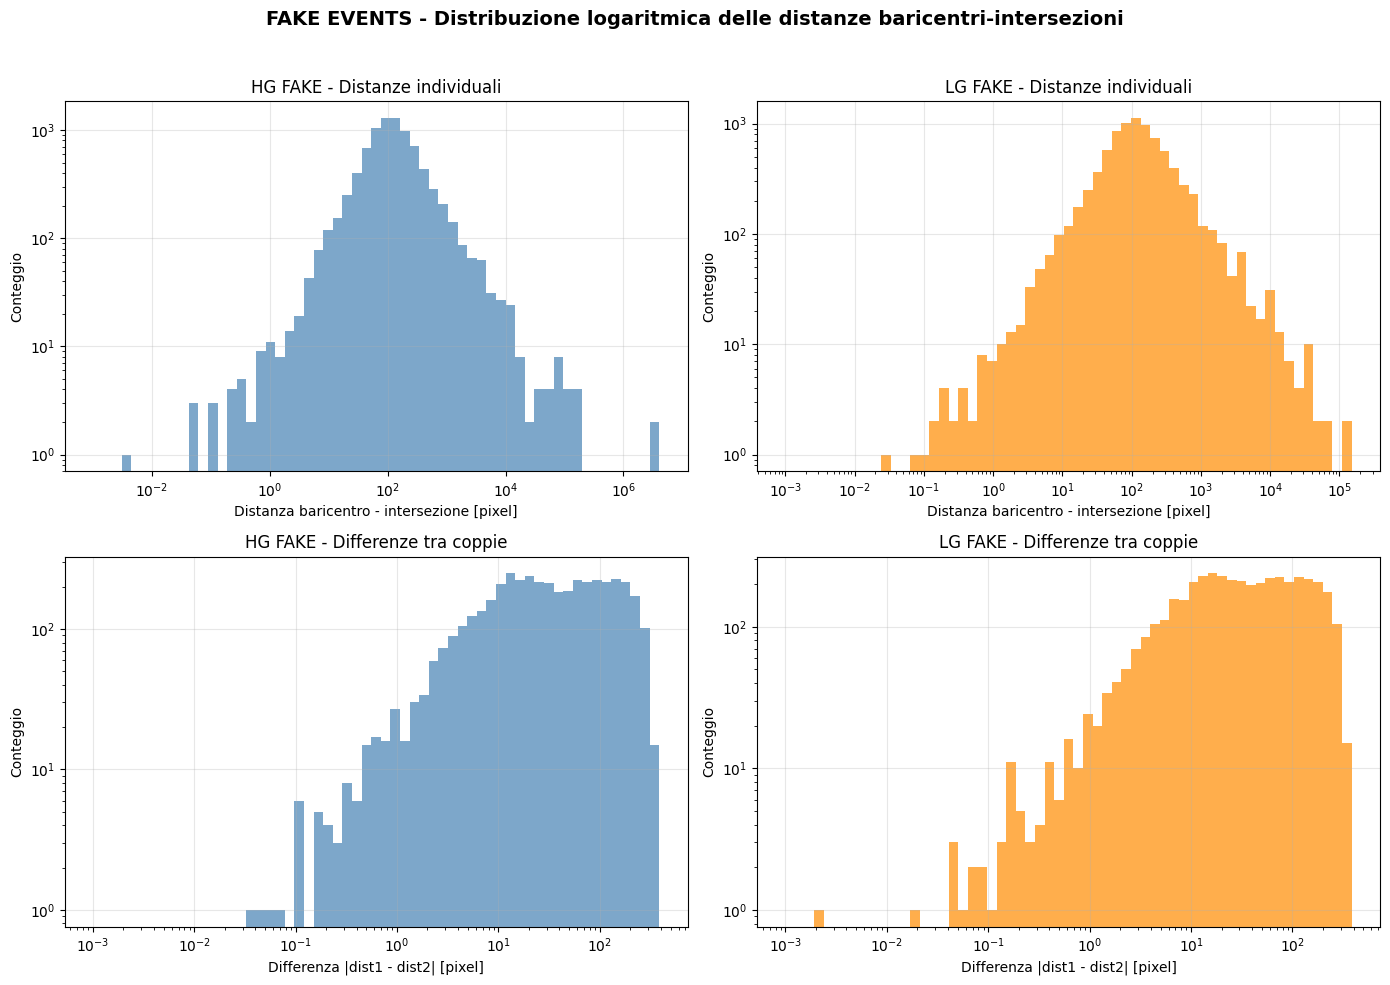


STATISTICHE DISTANZE BARICENTRI-INTERSEZIONI (FAKE EVENTS)

HG FAKE - Distanze individuali:
  N. totale: 8516
  Media: 1462.16 pixel
  Mediana: 114.93 pixel
  Max: 3673332.62 pixel

HG FAKE - Differenze tra coppie:
  N. totale: 4258
  Media: 62.28 pixel
  Mediana: 30.20 pixel
  Max: 351.14 pixel

LG FAKE - Distanze individuali:
  N. totale: 8516
  Media: 465.33 pixel
  Mediana: 115.38 pixel
  Max: 136472.38 pixel

LG FAKE - Differenze tra coppie:
  N. totale: 4258
  Media: 61.98 pixel
  Mediana: 30.67 pixel
  Max: 348.74 pixel


In [28]:
###======================== DISTANZA CENTROIDE INTERSEZIONE (FAKE EVENTS) =================================

# Separiamo HG e LG in DataFrame più comodi per fake events
dfR_f_hg = pd.DataFrame([{
    "fevent": r["fevent"],
    "event": r["event"],
    "mcrun": r["mcrun"],
    "tel": r["HG"]["tel"],
    "p0": r["HG"]["p0"],
    "d": r["HG"]["d"]
} for r in results_f])

dfR_f_lg = pd.DataFrame([{
    "fevent": r["fevent"],
    "event": r["event"],
    "mcrun": r["mcrun"],
    "tel": r["LG"]["tel"],
    "p0": r["LG"]["p0"],
    "d": r["LG"]["d"]
} for r in results_f])

# Calcola per HG fake (riusa la funzione intersection_distances già definita)
distances_hg_f = []
diff_distances_hg_f = []
for fevent, df_evt in dfR_f_hg.groupby("fevent"):
    dists, diffs = intersection_distances(df_evt)
    distances_hg_f.extend(dists)
    diff_distances_hg_f.extend(diffs)

# Calcola per LG fake
distances_lg_f = []
diff_distances_lg_f = []
for fevent, df_evt in dfR_f_lg.groupby("fevent"):
    dists, diffs = intersection_distances(df_evt)
    distances_lg_f.extend(dists)
    diff_distances_lg_f.extend(diffs)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# HG - Distanze individuali
axes[0, 0].hist(distances_hg_f, bins=smart_bins(np.array(distances_hg_f)), color='steelblue', alpha=0.7)
axes[0, 0].set_xscale('log')
axes[0, 0].set_yscale('log')
axes[0, 0].set_xlabel("Distanza baricentro - intersezione [pixel]")
axes[0, 0].set_ylabel("Conteggio")
axes[0, 0].set_title("HG FAKE - Distanze individuali")
axes[0, 0].grid(True, alpha=0.3)

# LG - Distanze individuali
axes[0, 1].hist(distances_lg_f, bins=smart_bins(np.array(distances_lg_f)), color='darkorange', alpha=0.7)
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xlabel("Distanza baricentro - intersezione [pixel]")
axes[0, 1].set_ylabel("Conteggio")
axes[0, 1].set_title("LG FAKE - Distanze individuali")
axes[0, 1].grid(True, alpha=0.3)

# HG - Differenze
axes[1, 0].hist(diff_distances_hg_f, bins=smart_bins(np.array(diff_distances_hg_f)), color='steelblue', alpha=0.7)
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel("Differenza |dist1 - dist2| [pixel]")
axes[1, 0].set_ylabel("Conteggio")
axes[1, 0].set_title("HG FAKE - Differenze tra coppie")
axes[1, 0].grid(True, alpha=0.3)

# LG - Differenze
axes[1, 1].hist(diff_distances_lg_f, bins=smart_bins(np.array(diff_distances_lg_f)), color='darkorange', alpha=0.7)
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].set_xlabel("Differenza |dist1 - dist2| [pixel]")
axes[1, 1].set_ylabel("Conteggio")
axes[1, 1].set_title("LG FAKE - Differenze tra coppie")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle("FAKE EVENTS - Distribuzione logaritmica delle distanze baricentri-intersezioni", 
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Statistiche
print("\n" + "="*60)
print("STATISTICHE DISTANZE BARICENTRI-INTERSEZIONI (FAKE EVENTS)")
print("="*60)

print(f"\nHG FAKE - Distanze individuali:")
print(f"  N. totale: {len(distances_hg_f)}")
print(f"  Media: {np.mean(distances_hg_f):.2f} pixel")
print(f"  Mediana: {np.median(distances_hg_f):.2f} pixel")
print(f"  Max: {np.max(distances_hg_f):.2f} pixel")

print(f"\nHG FAKE - Differenze tra coppie:")
print(f"  N. totale: {len(diff_distances_hg_f)}")
print(f"  Media: {np.mean(diff_distances_hg_f):.2f} pixel")
print(f"  Mediana: {np.median(diff_distances_hg_f):.2f} pixel")
print(f"  Max: {np.max(diff_distances_hg_f):.2f} pixel")

print(f"\nLG FAKE - Distanze individuali:")
print(f"  N. totale: {len(distances_lg_f)}")
print(f"  Media: {np.mean(distances_lg_f):.2f} pixel")
print(f"  Mediana: {np.median(distances_lg_f):.2f} pixel")
print(f"  Max: {np.max(distances_lg_f):.2f} pixel")

print(f"\nLG FAKE - Differenze tra coppie:")
print(f"  N. totale: {len(diff_distances_lg_f)}")
print(f"  Media: {np.mean(diff_distances_lg_f):.2f} pixel")
print(f"  Mediana: {np.median(diff_distances_lg_f):.2f} pixel")
print(f"  Max: {np.max(diff_distances_lg_f):.2f} pixel")

print("="*60)

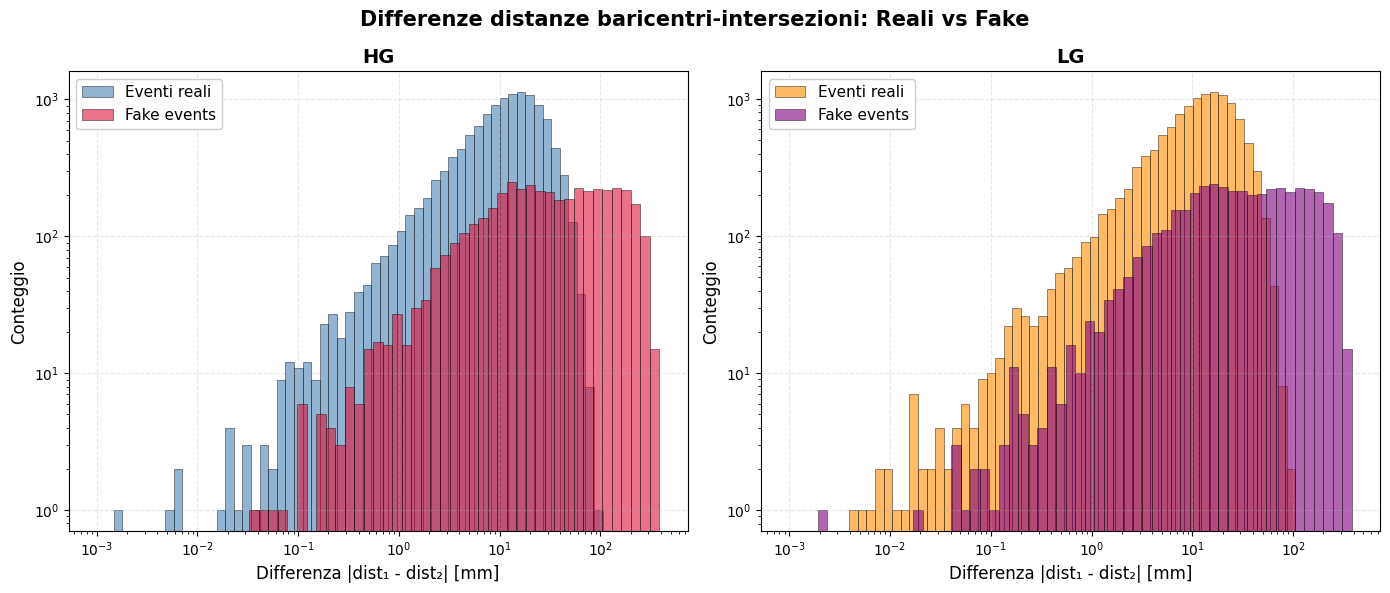

In [29]:
# Plot sovrapposizione differenze
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# HG - Differenze sovrapposte
axes[0].hist(diff_distances_hg, bins=smart_bins(np.array(diff_distances_hg)), 
             color='steelblue', alpha=0.6, label='Eventi reali', edgecolor='black', linewidth=0.5)
axes[0].hist(diff_distances_hg_f, bins=smart_bins(np.array(diff_distances_hg_f)), 
             color='crimson', alpha=0.6, label='Fake events', edgecolor='black', linewidth=0.5)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel("Differenza |dist₁ - dist₂| [mm]", fontsize=12)
axes[0].set_ylabel("Conteggio", fontsize=12)
axes[0].set_title("HG", fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11, framealpha=0.95)
axes[0].grid(True, alpha=0.3, linestyle='--')

# LG - Differenze sovrapposte
axes[1].hist(diff_distances_lg, bins=smart_bins(np.array(diff_distances_lg)), 
             color='darkorange', alpha=0.6, label='Eventi reali', edgecolor='black', linewidth=0.5)
axes[1].hist(diff_distances_lg_f, bins=smart_bins(np.array(diff_distances_lg_f)), 
             color='purple', alpha=0.6, label='Fake events', edgecolor='black', linewidth=0.5)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel("Differenza |dist₁ - dist₂| [mm]", fontsize=12)
axes[1].set_ylabel("Conteggio", fontsize=12)
axes[1].set_title("LG", fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11, framealpha=0.95)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.suptitle("Differenze distanze baricentri-intersezioni: Reali vs Fake", 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

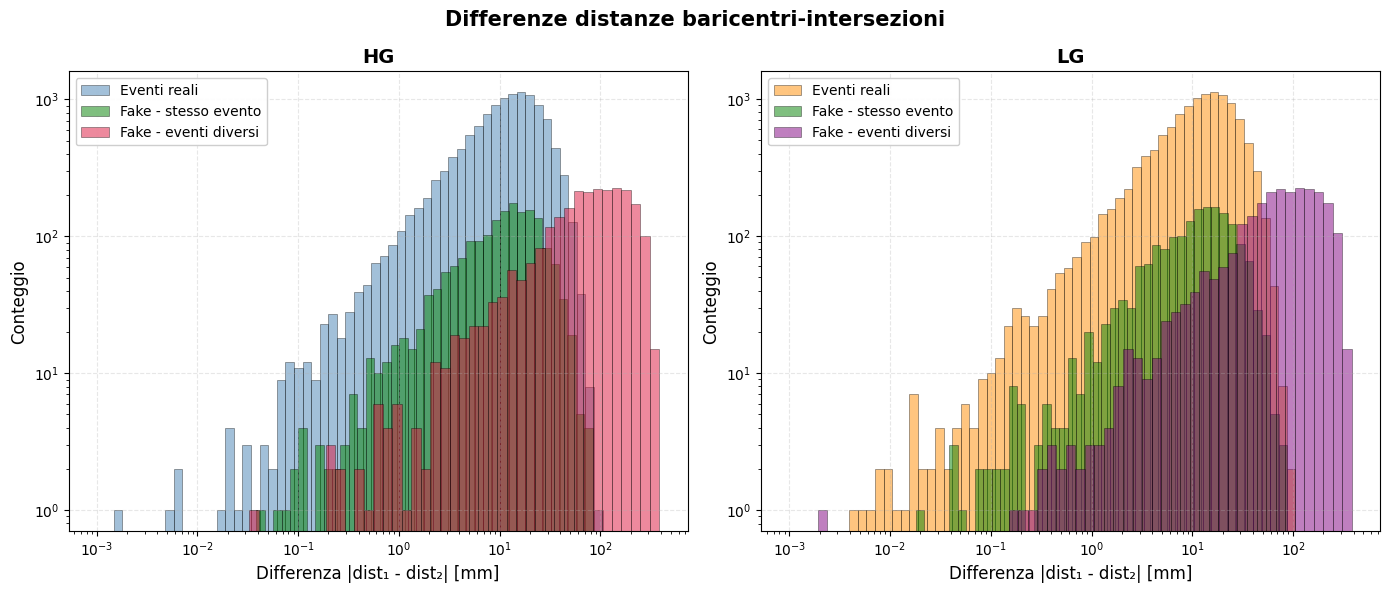


STATISTICHE DIFFERENZE DISTANZE BARICENTRI-INTERSEZIONI

HG - Eventi reali                        N=12173  μ=14.2  median=11.6
HG - Fake stesso evento                  N=1794   μ=13.7  median=11.2
HG - Fake eventi diversi                 N=2464   μ=97.7  median=78.3

LG - Eventi reali                        N=12173  μ=14.5  median=11.7
LG - Fake stesso evento                  N=1794   μ=13.9  median=11.3
LG - Fake eventi diversi                 N=2464   μ=97.0  median=77.2


In [30]:
###======================== DISTANZA CENTROIDE INTERSEZIONE (FAKE EVENTS - SEPARATI) =================================

# Separiamo HG e LG in DataFrame più comodi per fake events
dfR_f_hg = pd.DataFrame([{
    "fevent": r["fevent"],
    "event": r["event"],
    "mcrun": r["mcrun"],
    "tel": r["HG"]["tel"],
    "p0": r["HG"]["p0"],
    "d": r["HG"]["d"]
} for r in results_f])

dfR_f_lg = pd.DataFrame([{
    "fevent": r["fevent"],
    "event": r["event"],
    "mcrun": r["mcrun"],
    "tel": r["LG"]["tel"],
    "p0": r["LG"]["p0"],
    "d": r["LG"]["d"]
} for r in results_f])

from itertools import combinations

def intersection_distances_separated(df_evt):
    """
    df_evt: DataFrame di un singolo fake event (fevent)
    Restituisce due tuple separate:
    - same_event: (distances, diff_distances) per rette dello stesso (event, mcrun)
    - diff_event: (distances, diff_distances) per rette di (event, mcrun) diversi
    """
    p0s = np.vstack(df_evt["p0"].values)
    ds = np.vstack(df_evt["d"].values)
    events = df_evt["event"].values
    mcruns = df_evt["mcrun"].values
    
    # Stesso evento
    distances_same = []
    diff_distances_same = []
    
    # Eventi diversi
    distances_diff = []
    diff_distances_diff = []

    for (i, (p1, d1, ev1, mc1)), (j, (p2, d2, ev2, mc2)) in combinations(
        enumerate(zip(p0s, ds, events, mcruns)), 2
    ):
        # controllo quasi-parallelismo
        det = d1[0]*d2[1] - d1[1]*d2[0]
        if np.abs(det) < 1e-6:
            continue

        # calcolo intersezione
        A = np.array([d1, -d2]).T
        b = p2 - p1
        detA = np.linalg.det(A)
        if np.abs(detA) < 1e-6:
            continue
            
        t = np.linalg.solve(A, b)[0]
        P_inter = p1 + t*d1

        # distanza di ciascun baricentro dall'intersezione
        dist1 = np.linalg.norm(p1 - P_inter)
        dist2 = np.linalg.norm(p2 - P_inter)
        diff_dist = np.abs(dist1 - dist2)
        
        # Verifica se stesso evento
        if (ev1 == ev2) and (mc1 == mc2):
            # Stesso evento reale
            distances_same.append(dist1)
            distances_same.append(dist2)
            diff_distances_same.append(diff_dist)
        else:
            # Eventi diversi
            distances_diff.append(dist1)
            distances_diff.append(dist2)
            diff_distances_diff.append(diff_dist)

    return (distances_same, diff_distances_same), (distances_diff, diff_distances_diff)

# Calcola per HG fake
distances_hg_f_same = []
diff_distances_hg_f_same = []
distances_hg_f_diff = []
diff_distances_hg_f_diff = []

for fevent, df_evt in dfR_f_hg.groupby("fevent"):
    (dists_same, diffs_same), (dists_diff, diffs_diff) = intersection_distances_separated(df_evt)
    distances_hg_f_same.extend(dists_same)
    diff_distances_hg_f_same.extend(diffs_same)
    distances_hg_f_diff.extend(dists_diff)
    diff_distances_hg_f_diff.extend(diffs_diff)

# Calcola per LG fake
distances_lg_f_same = []
diff_distances_lg_f_same = []
distances_lg_f_diff = []
diff_distances_lg_f_diff = []

for fevent, df_evt in dfR_f_lg.groupby("fevent"):
    (dists_same, diffs_same), (dists_diff, diffs_diff) = intersection_distances_separated(df_evt)
    distances_lg_f_same.extend(dists_same)
    diff_distances_lg_f_same.extend(diffs_same)
    distances_lg_f_diff.extend(dists_diff)
    diff_distances_lg_f_diff.extend(diffs_diff)

# Plot sovrapposizione differenze
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# HG - Differenze sovrapposte
if len(diff_distances_hg) > 0:
    axes[0].hist(diff_distances_hg, bins=smart_bins(np.array(diff_distances_hg)), 
                 color='steelblue', alpha=0.5, label='Eventi reali', edgecolor='black', linewidth=0.5)
if len(diff_distances_hg_f_same) > 0:
    axes[0].hist(diff_distances_hg_f_same, bins=smart_bins(np.array(diff_distances_hg_f_same)), 
                 color='green', alpha=0.5, label='Fake - stesso evento', edgecolor='black', linewidth=0.5)
if len(diff_distances_hg_f_diff) > 0:
    axes[0].hist(diff_distances_hg_f_diff, bins=smart_bins(np.array(diff_distances_hg_f_diff)), 
                 color='crimson', alpha=0.5, label='Fake - eventi diversi', edgecolor='black', linewidth=0.5)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel("Differenza |dist₁ - dist₂| [mm]", fontsize=12)
axes[0].set_ylabel("Conteggio", fontsize=12)
axes[0].set_title("HG", fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10, framealpha=0.95)
axes[0].grid(True, alpha=0.3, linestyle='--')

# LG - Differenze sovrapposte
if len(diff_distances_lg) > 0:
    axes[1].hist(diff_distances_lg, bins=smart_bins(np.array(diff_distances_lg)), 
                 color='darkorange', alpha=0.5, label='Eventi reali', edgecolor='black', linewidth=0.5)
if len(diff_distances_lg_f_same) > 0:
    axes[1].hist(diff_distances_lg_f_same, bins=smart_bins(np.array(diff_distances_lg_f_same)), 
                 color='green', alpha=0.5, label='Fake - stesso evento', edgecolor='black', linewidth=0.5)
if len(diff_distances_lg_f_diff) > 0:
    axes[1].hist(diff_distances_lg_f_diff, bins=smart_bins(np.array(diff_distances_lg_f_diff)), 
                 color='purple', alpha=0.5, label='Fake - eventi diversi', edgecolor='black', linewidth=0.5)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel("Differenza |dist₁ - dist₂| [mm]", fontsize=12)
axes[1].set_ylabel("Conteggio", fontsize=12)
axes[1].set_title("LG", fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10, framealpha=0.95)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.suptitle("Differenze distanze baricentri-intersezioni", 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Statistiche
print("\n" + "="*70)
print("STATISTICHE DIFFERENZE DISTANZE BARICENTRI-INTERSEZIONI")
print("="*70)

print(f"\n{'HG - Eventi reali':<40} N={len(diff_distances_hg):<6} μ={np.mean(diff_distances_hg):.1f}  median={np.median(diff_distances_hg):.1f}")
print(f"{'HG - Fake stesso evento':<40} N={len(diff_distances_hg_f_same):<6} μ={np.mean(diff_distances_hg_f_same) if len(diff_distances_hg_f_same)>0 else 0:.1f}  median={np.median(diff_distances_hg_f_same) if len(diff_distances_hg_f_same)>0 else 0:.1f}")
print(f"{'HG - Fake eventi diversi':<40} N={len(diff_distances_hg_f_diff):<6} μ={np.mean(diff_distances_hg_f_diff) if len(diff_distances_hg_f_diff)>0 else 0:.1f}  median={np.median(diff_distances_hg_f_diff) if len(diff_distances_hg_f_diff)>0 else 0:.1f}")

print(f"\n{'LG - Eventi reali':<40} N={len(diff_distances_lg):<6} μ={np.mean(diff_distances_lg):.1f}  median={np.median(diff_distances_lg):.1f}")
print(f"{'LG - Fake stesso evento':<40} N={len(diff_distances_lg_f_same):<6} μ={np.mean(diff_distances_lg_f_same) if len(diff_distances_lg_f_same)>0 else 0:.1f}  median={np.median(diff_distances_lg_f_same) if len(diff_distances_lg_f_same)>0 else 0:.1f}")
print(f"{'LG - Fake eventi diversi':<40} N={len(diff_distances_lg_f_diff):<6} μ={np.mean(diff_distances_lg_f_diff) if len(diff_distances_lg_f_diff)>0 else 0:.1f}  median={np.median(diff_distances_lg_f_diff) if len(diff_distances_lg_f_diff)>0 else 0:.1f}")

print("="*70)

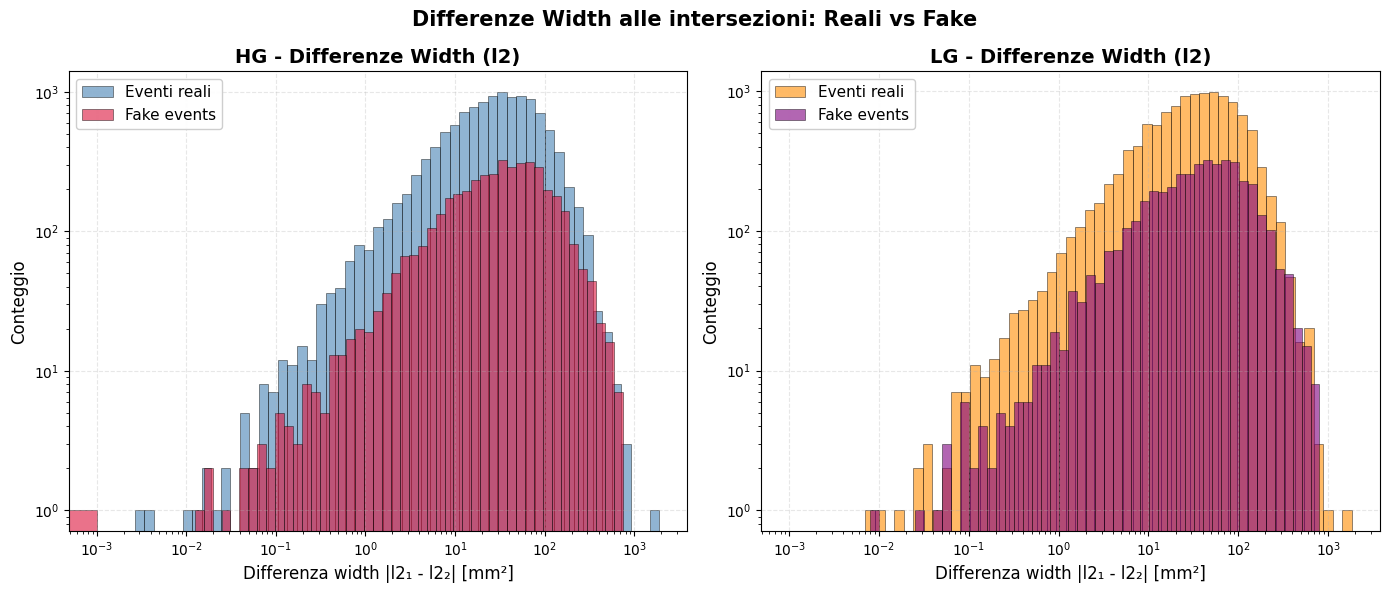


STATISTICHE DIFFERENZE WIDTH (l2) ALLE INTERSEZIONI

HG - Eventi reali                        N=12173  μ=47.041  median=27.633  max=1736.507
HG - Fake events                         N=4258   μ=58.158  median=33.382  max=680.874

LG - Eventi reali                        N=12173  μ=52.971  median=32.180  max=1671.404
LG - Fake events                         N=4258   μ=64.929  median=38.642  max=728.955


In [ ]:
###======================== DIFFERENZE WIDTH ALLE INTERSEZIONI =================================

from itertools import combinations

def intersection_width_diff(dfR_full_evt):
    """
    dfR_full_evt: DataFrame di un singolo evento con tutti i dati (p0, d, l2)
    
    Restituisce:
    - diff_widths: lista delle differenze |l2_1 - l2_2| per ogni coppia
    """
    p0s = np.vstack(dfR_full_evt["p0"].values)
    ds = np.vstack(dfR_full_evt["d"].values)
    l2s = dfR_full_evt["l2"].values
    
    diff_widths = []

    for (i, (p1, d1, l2_1)), (j, (p2, d2, l2_2)) in combinations(
        enumerate(zip(p0s, ds, l2s)), 2
    ):
        # controllo quasi-parallelismo
        det = d1[0]*d2[1] - d1[1]*d2[0]
        if np.abs(det) < 1e-6:
            continue

        # calcolo intersezione (per verificare che esista)
        A = np.array([d1, -d2]).T
        b = p2 - p1
        detA = np.linalg.det(A)
        if np.abs(detA) < 1e-6:
            continue
        
        # Se l'intersezione esiste, calcola la differenza
        diff_widths.append(np.abs(l2_1 - l2_2))

    return diff_widths


# ======================= EVENTI REALI =======================

# Crea DataFrame completo con l2 per HG
dfR_hg_full = pd.DataFrame([{
    "revent": r["revent"],
    "event": r["event"],
    "mcrun": r["mcrun"],
    "tel": r["HG"]["tel"],
    "p0": r["HG"]["p0"],
    "d": r["HG"]["d"],
    "l2": r["HG"]["l2"]
} for r in results])

# Crea DataFrame completo con l2 per LG
dfR_lg_full = pd.DataFrame([{
    "revent": r["revent"],
    "event": r["event"],
    "mcrun": r["mcrun"],
    "tel": r["LG"]["tel"],
    "p0": r["LG"]["p0"],
    "d": r["LG"]["d"],
    "l2": r["LG"]["l2"]
} for r in results])

# Calcola per HG reali
diff_widths_hg = []
for revent, df_evt in dfR_hg_full.groupby("revent"):
    widths = intersection_width_diff(df_evt)
    diff_widths_hg.extend(widths)

# Calcola per LG reali
diff_widths_lg = []
for revent, df_evt in dfR_lg_full.groupby("revent"):
    widths = intersection_width_diff(df_evt)
    diff_widths_lg.extend(widths)


# ======================= FAKE EVENTS =======================

# Crea DataFrame completo con l2 per HG fake
dfR_f_hg_full = pd.DataFrame([{
    "fevent": r["fevent"],
    "event": r["event"],
    "mcrun": r["mcrun"],
    "tel": r["HG"]["tel"],
    "p0": r["HG"]["p0"],
    "d": r["HG"]["d"],
    "l2": r["HG"]["l2"]
} for r in results_f])

# Crea DataFrame completo con l2 per LG fake
dfR_f_lg_full = pd.DataFrame([{
    "fevent": r["fevent"],
    "event": r["event"],
    "mcrun": r["mcrun"],
    "tel": r["LG"]["tel"],
    "p0": r["LG"]["p0"],
    "d": r["LG"]["d"],
    "l2": r["LG"]["l2"]
} for r in results_f])

# Calcola per HG fake
diff_widths_hg_f = []
for fevent, df_evt in dfR_f_hg_full.groupby("fevent"):
    widths = intersection_width_diff(df_evt)
    diff_widths_hg_f.extend(widths)

# Calcola per LG fake
diff_widths_lg_f = []
for fevent, df_evt in dfR_f_lg_full.groupby("fevent"):
    widths = intersection_width_diff(df_evt)
    diff_widths_lg_f.extend(widths)


# ======================= PLOT SOVRAPPOSIZIONE =======================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# HG - Differenze Width (l2)
if len(diff_widths_hg) > 0:
    axes[0].hist(diff_widths_hg, bins=smart_bins(np.array(diff_widths_hg)), 
                 color='steelblue', alpha=0.6, label='Eventi reali', 
                 edgecolor='black', linewidth=0.5)
if len(diff_widths_hg_f) > 0:
    axes[0].hist(diff_widths_hg_f, bins=smart_bins(np.array(diff_widths_hg_f)), 
                 color='crimson', alpha=0.6, label='Fake events', 
                 edgecolor='black', linewidth=0.5)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel("Differenza width |l2₁ - l2₂| [mm]", fontsize=12)
axes[0].set_ylabel("Conteggio", fontsize=12)
axes[0].set_title("HG - Differenze Width (l2)", fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11, framealpha=0.95)
axes[0].grid(True, alpha=0.3, linestyle='--')

# LG - Differenze Width (l2)
if len(diff_widths_lg) > 0:
    axes[1].hist(diff_widths_lg, bins=smart_bins(np.array(diff_widths_lg)), 
                 color='darkorange', alpha=0.6, label='Eventi reali', 
                 edgecolor='black', linewidth=0.5)
if len(diff_widths_lg_f) > 0:
    axes[1].hist(diff_widths_lg_f, bins=smart_bins(np.array(diff_widths_lg_f)), 
                 color='purple', alpha=0.6, label='Fake events', 
                 edgecolor='black', linewidth=0.5)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel("Differenza width |l2₁ - l2₂| [mm]", fontsize=12)
axes[1].set_ylabel("Conteggio", fontsize=12)
axes[1].set_title("LG - Differenze Width (l2)", fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11, framealpha=0.95)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.suptitle("Differenze Width alle intersezioni: Reali vs Fake", 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


# ======================= STATISTICHE =======================
print("\n" + "="*80)
print("STATISTICHE DIFFERENZE WIDTH (l2) ALLE INTERSEZIONI")
print("="*80)

print(f"\n{'HG - Eventi reali':<40} N={len(diff_widths_hg):<6} μ={np.mean(diff_widths_hg):.3f}  median={np.median(diff_widths_hg):.3f}  max={np.max(diff_widths_hg):.3f}")
print(f"{'HG - Fake events':<40} N={len(diff_widths_hg_f):<6} μ={np.mean(diff_widths_hg_f) if len(diff_widths_hg_f)>0 else 0:.3f}  median={np.median(diff_widths_hg_f) if len(diff_widths_hg_f)>0 else 0:.3f}  max={np.max(diff_widths_hg_f) if len(diff_widths_hg_f)>0 else 0:.3f}")
print(f"\n{'LG - Eventi reali':<40} N={len(diff_widths_lg):<6} μ={np.mean(diff_widths_lg):.3f}  median={np.median(diff_widths_lg):.3f}  max={np.max(diff_widths_lg):.3f}")
print(f"{'LG - Fake events':<40} N={len(diff_widths_lg_f):<6} μ={np.mean(diff_widths_lg_f) if len(diff_widths_lg_f)>0 else 0:.3f}  median={np.median(diff_widths_lg_f) if len(diff_widths_lg_f)>0 else 0:.3f}  max={np.max(diff_widths_lg_f) if len(diff_widths_lg_f)>0 else 0:.3f}")

print("="*80)

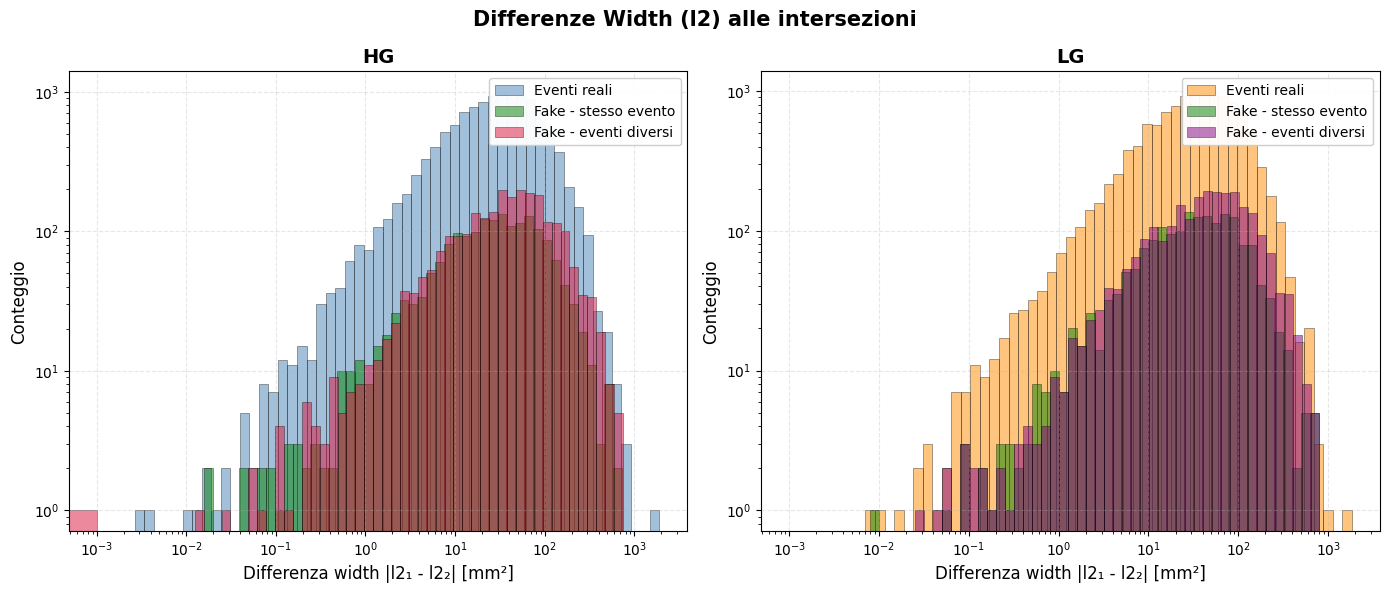


STATISTICHE DIFFERENZE WIDTH (l2) ALLE INTERSEZIONI

HG - Eventi reali                        N=12173  μ=47.041  median=27.633
HG - Fake stesso evento                  N=1794   μ=49.905  median=27.264
HG - Fake eventi diversi                 N=2464   μ=64.168  median=37.864

LG - Eventi reali                        N=12173  μ=52.971  median=32.180
LG - Fake stesso evento                  N=1794   μ=55.986  median=31.682
LG - Fake eventi diversi                 N=2464   μ=71.439  median=43.742


In [34]:
###======================== DIFFERENZE WIDTH ALLE INTERSEZIONI (FAKE EVENTS - SEPARATI) =================================

from itertools import combinations

def intersection_width_diff_separated(df_evt):
    """
    df_evt: DataFrame di un singolo fake event (fevent) con p0, d, l2, event, mcrun
    Restituisce due liste separate:
    - diff_widths_same: differenze |l2_1 - l2_2| per rette dello stesso (event, mcrun)
    - diff_widths_diff: differenze |l2_1 - l2_2| per rette di (event, mcrun) diversi
    """
    p0s = np.vstack(df_evt["p0"].values)
    ds = np.vstack(df_evt["d"].values)
    l2s = df_evt["l2"].values
    events = df_evt["event"].values
    mcruns = df_evt["mcrun"].values
    
    # Stesso evento
    diff_widths_same = []
    
    # Eventi diversi
    diff_widths_diff = []

    for (i, (p1, d1, l2_1, ev1, mc1)), (j, (p2, d2, l2_2, ev2, mc2)) in combinations(
        enumerate(zip(p0s, ds, l2s, events, mcruns)), 2
    ):
        # controllo quasi-parallelismo
        det = d1[0]*d2[1] - d1[1]*d2[0]
        if np.abs(det) < 1e-6:
            continue

        # calcolo intersezione (per verificare che esista)
        A = np.array([d1, -d2]).T
        b = p2 - p1
        detA = np.linalg.det(A)
        if np.abs(detA) < 1e-6:
            continue
        
        # Differenza width
        diff_width = np.abs(l2_1 - l2_2)
        
        # Verifica se stesso evento
        if (ev1 == ev2) and (mc1 == mc2):
            # Stesso evento reale
            diff_widths_same.append(diff_width)
        else:
            # Eventi diversi
            diff_widths_diff.append(diff_width)

    return diff_widths_same, diff_widths_diff

# ======================= FAKE EVENTS - SEPARATI =======================

# Calcola per HG fake
diff_widths_hg_f_same = []
diff_widths_hg_f_diff = []

for fevent, df_evt in dfR_f_hg_full.groupby("fevent"):
    widths_same, widths_diff = intersection_width_diff_separated(df_evt)
    diff_widths_hg_f_same.extend(widths_same)
    diff_widths_hg_f_diff.extend(widths_diff)

# Calcola per LG fake
diff_widths_lg_f_same = []
diff_widths_lg_f_diff = []

for fevent, df_evt in dfR_f_lg_full.groupby("fevent"):
    widths_same, widths_diff = intersection_width_diff_separated(df_evt)
    diff_widths_lg_f_same.extend(widths_same)
    diff_widths_lg_f_diff.extend(widths_diff)


# ======================= PLOT SOVRAPPOSIZIONE =======================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# HG - Differenze width sovrapposte
if len(diff_widths_hg) > 0:
    axes[0].hist(diff_widths_hg, bins=smart_bins(np.array(diff_widths_hg)), 
                 color='steelblue', alpha=0.5, label='Eventi reali', 
                 edgecolor='black', linewidth=0.5)
if len(diff_widths_hg_f_same) > 0:
    axes[0].hist(diff_widths_hg_f_same, bins=smart_bins(np.array(diff_widths_hg_f_same)), 
                 color='green', alpha=0.5, label='Fake - stesso evento', 
                 edgecolor='black', linewidth=0.5)
if len(diff_widths_hg_f_diff) > 0:
    axes[0].hist(diff_widths_hg_f_diff, bins=smart_bins(np.array(diff_widths_hg_f_diff)), 
                 color='crimson', alpha=0.5, label='Fake - eventi diversi', 
                 edgecolor='black', linewidth=0.5)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel("Differenza width |l2₁ - l2₂| [mm²]", fontsize=12)
axes[0].set_ylabel("Conteggio", fontsize=12)
axes[0].set_title("HG", fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10, framealpha=0.95, loc='upper right')
axes[0].grid(True, alpha=0.3, linestyle='--')

# LG - Differenze width sovrapposte
if len(diff_widths_lg) > 0:
    axes[1].hist(diff_widths_lg, bins=smart_bins(np.array(diff_widths_lg)), 
                 color='darkorange', alpha=0.5, label='Eventi reali', 
                 edgecolor='black', linewidth=0.5)
if len(diff_widths_lg_f_same) > 0:
    axes[1].hist(diff_widths_lg_f_same, bins=smart_bins(np.array(diff_widths_lg_f_same)), 
                 color='green', alpha=0.5, label='Fake - stesso evento', 
                 edgecolor='black', linewidth=0.5)
if len(diff_widths_lg_f_diff) > 0:
    axes[1].hist(diff_widths_lg_f_diff, bins=smart_bins(np.array(diff_widths_lg_f_diff)), 
                 color='purple', alpha=0.5, label='Fake - eventi diversi', 
                 edgecolor='black', linewidth=0.5)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel("Differenza width |l2₁ - l2₂| [mm²]", fontsize=12)
axes[1].set_ylabel("Conteggio", fontsize=12)
axes[1].set_title("LG", fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10, framealpha=0.95, loc='upper right')
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.suptitle("Differenze Width (l2) alle intersezioni", 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


# ======================= STATISTICHE =======================
print("\n" + "="*80)
print("STATISTICHE DIFFERENZE WIDTH (l2) ALLE INTERSEZIONI")
print("="*80)

print(f"\n{'HG - Eventi reali':<40} N={len(diff_widths_hg):<6} μ={np.mean(diff_widths_hg):.3f}  median={np.median(diff_widths_hg):.3f}")
print(f"{'HG - Fake stesso evento':<40} N={len(diff_widths_hg_f_same):<6} μ={np.mean(diff_widths_hg_f_same) if len(diff_widths_hg_f_same)>0 else 0:.3f}  median={np.median(diff_widths_hg_f_same) if len(diff_widths_hg_f_same)>0 else 0:.3f}")
print(f"{'HG - Fake eventi diversi':<40} N={len(diff_widths_hg_f_diff):<6} μ={np.mean(diff_widths_hg_f_diff) if len(diff_widths_hg_f_diff)>0 else 0:.3f}  median={np.median(diff_widths_hg_f_diff) if len(diff_widths_hg_f_diff)>0 else 0:.3f}")

print(f"\n{'LG - Eventi reali':<40} N={len(diff_widths_lg):<6} μ={np.mean(diff_widths_lg):.3f}  median={np.median(diff_widths_lg):.3f}")
print(f"{'LG - Fake stesso evento':<40} N={len(diff_widths_lg_f_same):<6} μ={np.mean(diff_widths_lg_f_same) if len(diff_widths_lg_f_same)>0 else 0:.3f}  median={np.median(diff_widths_lg_f_same) if len(diff_widths_lg_f_same)>0 else 0:.3f}")
print(f"{'LG - Fake eventi diversi':<40} N={len(diff_widths_lg_f_diff):<6} μ={np.mean(diff_widths_lg_f_diff) if len(diff_widths_lg_f_diff)>0 else 0:.3f}  median={np.median(diff_widths_lg_f_diff) if len(diff_widths_lg_f_diff)>0 else 0:.3f}")

print("="*80)

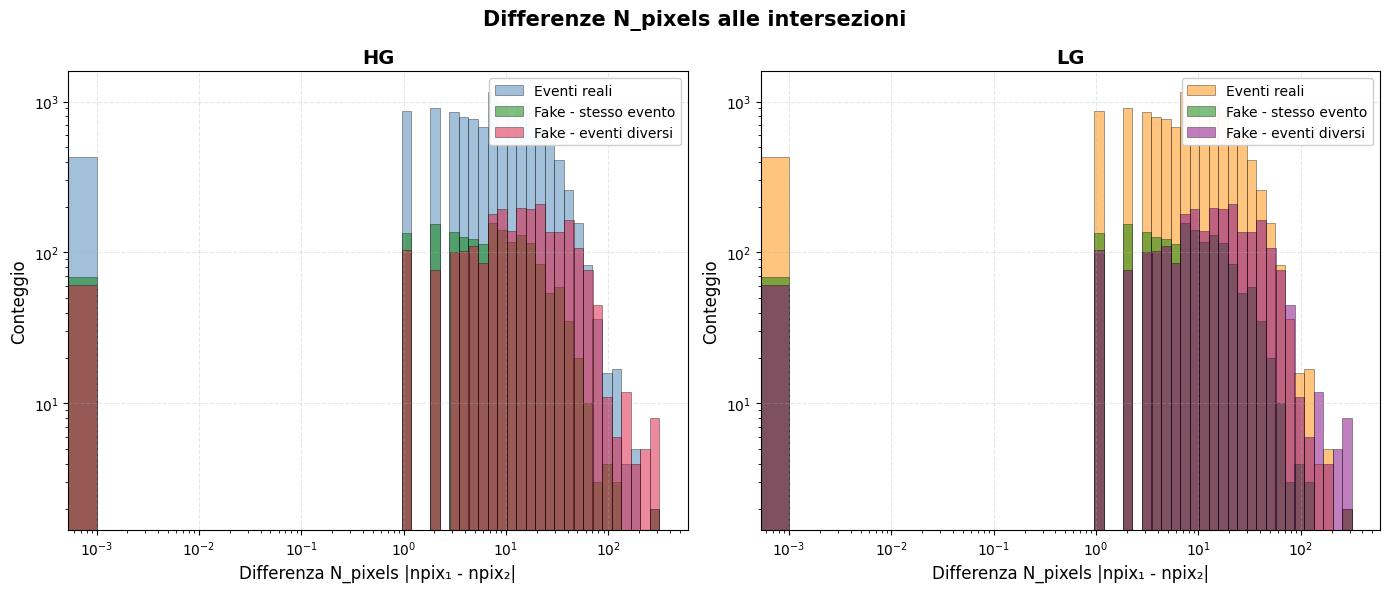


STATISTICHE DIFFERENZE N_PIXELS ALLE INTERSEZIONI

HG - Eventi reali                        N=12173  μ=11.9  median=8.0
HG - Fake stesso evento                  N=1794   μ=11.2  median=7.0
HG - Fake eventi diversi                 N=2464   μ=21.8  median=14.0

LG - Eventi reali                        N=12173  μ=11.9  median=8.0
LG - Fake stesso evento                  N=1794   μ=11.2  median=7.0
LG - Fake eventi diversi                 N=2464   μ=21.8  median=14.0


In [35]:
###======================== DIFFERENZE N_PIXELS ALLE INTERSEZIONI (FAKE EVENTS - SEPARATI) =================================


def intersection_npixels_diff_separated(df_evt):
    """
    df_evt: DataFrame di un singolo fake event (fevent) con p0, d, n_pixels, event, mcrun
    Restituisce due liste separate:
    - diff_npixels_same: differenze |npix_1 - npix_2| per rette dello stesso (event, mcrun)
    - diff_npixels_diff: differenze |npix_1 - npix_2| per rette di (event, mcrun) diversi
    """
    p0s = np.vstack(df_evt["p0"].values)
    ds = np.vstack(df_evt["d"].values)
    npixs = df_evt["n_pixels"].values
    events = df_evt["event"].values
    mcruns = df_evt["mcrun"].values
    
    # Stesso evento
    diff_npixels_same = []
    
    # Eventi diversi
    diff_npixels_diff = []

    for (i, (p1, d1, npix_1, ev1, mc1)), (j, (p2, d2, npix_2, ev2, mc2)) in combinations(
        enumerate(zip(p0s, ds, npixs, events, mcruns)), 2
    ):
        # controllo quasi-parallelismo
        det = d1[0]*d2[1] - d1[1]*d2[0]
        if np.abs(det) < 1e-6:
            continue

        # calcolo intersezione (per verificare che esista)
        A = np.array([d1, -d2]).T
        b = p2 - p1
        detA = np.linalg.det(A)
        if np.abs(detA) < 1e-6:
            continue
        
        # Differenza n_pixels
        diff_npix = np.abs(npix_1 - npix_2)
        
        # Verifica se stesso evento
        if (ev1 == ev2) and (mc1 == mc2):
            # Stesso evento reale
            diff_npixels_same.append(diff_npix)
        else:
            # Eventi diversi
            diff_npixels_diff.append(diff_npix)

    return diff_npixels_same, diff_npixels_diff


# ======================= EVENTI REALI =======================

# Crea DataFrame completo con n_pixels per HG
dfR_hg_npix = pd.DataFrame([{
    "revent": r["revent"],
    "event": r["event"],
    "mcrun": r["mcrun"],
    "tel": r["HG"]["tel"],
    "p0": r["HG"]["p0"],
    "d": r["HG"]["d"],
    "n_pixels": r["n_pixels"]
} for r in results])

# Crea DataFrame completo con n_pixels per LG
dfR_lg_npix = pd.DataFrame([{
    "revent": r["revent"],
    "event": r["event"],
    "mcrun": r["mcrun"],
    "tel": r["LG"]["tel"],
    "p0": r["LG"]["p0"],
    "d": r["LG"]["d"],
    "n_pixels": r["n_pixels"]
} for r in results])

# Calcola per HG reali
diff_npixels_hg = []
for revent, df_evt in dfR_hg_npix.groupby("revent"):
    npixs = intersection_npixels_diff_separated(df_evt)
    # Per eventi reali non c'è separazione same/diff, prendi tutto
    diff_npixels_hg.extend(npixs[0])  # same (che è tutto per eventi reali)

# Calcola per LG reali
diff_npixels_lg = []
for revent, df_evt in dfR_lg_npix.groupby("revent"):
    npixs = intersection_npixels_diff_separated(df_evt)
    diff_npixels_lg.extend(npixs[0])  # same (che è tutto per eventi reali)


# ======================= FAKE EVENTS - SEPARATI =======================

# Crea DataFrame completo con n_pixels per HG fake
dfR_f_hg_npix = pd.DataFrame([{
    "fevent": r["fevent"],
    "event": r["event"],
    "mcrun": r["mcrun"],
    "tel": r["HG"]["tel"],
    "p0": r["HG"]["p0"],
    "d": r["HG"]["d"],
    "n_pixels": r["n_pixels"]
} for r in results_f])

# Crea DataFrame completo con n_pixels per LG fake
dfR_f_lg_npix = pd.DataFrame([{
    "fevent": r["fevent"],
    "event": r["event"],
    "mcrun": r["mcrun"],
    "tel": r["LG"]["tel"],
    "p0": r["LG"]["p0"],
    "d": r["LG"]["d"],
    "n_pixels": r["n_pixels"]
} for r in results_f])

# Calcola per HG fake
diff_npixels_hg_f_same = []
diff_npixels_hg_f_diff = []

for fevent, df_evt in dfR_f_hg_npix.groupby("fevent"):
    npixs_same, npixs_diff = intersection_npixels_diff_separated(df_evt)
    diff_npixels_hg_f_same.extend(npixs_same)
    diff_npixels_hg_f_diff.extend(npixs_diff)

# Calcola per LG fake
diff_npixels_lg_f_same = []
diff_npixels_lg_f_diff = []

for fevent, df_evt in dfR_f_lg_npix.groupby("fevent"):
    npixs_same, npixs_diff = intersection_npixels_diff_separated(df_evt)
    diff_npixels_lg_f_same.extend(npixs_same)
    diff_npixels_lg_f_diff.extend(npixs_diff)


# ======================= PLOT SOVRAPPOSIZIONE =======================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# HG - Differenze n_pixels sovrapposte
if len(diff_npixels_hg) > 0:
    axes[0].hist(diff_npixels_hg, bins=smart_bins(np.array(diff_npixels_hg)), 
                 color='steelblue', alpha=0.5, label='Eventi reali', 
                 edgecolor='black', linewidth=0.5)
if len(diff_npixels_hg_f_same) > 0:
    axes[0].hist(diff_npixels_hg_f_same, bins=smart_bins(np.array(diff_npixels_hg_f_same)), 
                 color='green', alpha=0.5, label='Fake - stesso evento', 
                 edgecolor='black', linewidth=0.5)
if len(diff_npixels_hg_f_diff) > 0:
    axes[0].hist(diff_npixels_hg_f_diff, bins=smart_bins(np.array(diff_npixels_hg_f_diff)), 
                 color='crimson', alpha=0.5, label='Fake - eventi diversi', 
                 edgecolor='black', linewidth=0.5)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel("Differenza N_pixels |npix₁ - npix₂|", fontsize=12)
axes[0].set_ylabel("Conteggio", fontsize=12)
axes[0].set_title("HG", fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10, framealpha=0.95, loc='upper right')
axes[0].grid(True, alpha=0.3, linestyle='--')

# LG - Differenze n_pixels sovrapposte
if len(diff_npixels_lg) > 0:
    axes[1].hist(diff_npixels_lg, bins=smart_bins(np.array(diff_npixels_lg)), 
                 color='darkorange', alpha=0.5, label='Eventi reali', 
                 edgecolor='black', linewidth=0.5)
if len(diff_npixels_lg_f_same) > 0:
    axes[1].hist(diff_npixels_lg_f_same, bins=smart_bins(np.array(diff_npixels_lg_f_same)), 
                 color='green', alpha=0.5, label='Fake - stesso evento', 
                 edgecolor='black', linewidth=0.5)
if len(diff_npixels_lg_f_diff) > 0:
    axes[1].hist(diff_npixels_lg_f_diff, bins=smart_bins(np.array(diff_npixels_lg_f_diff)), 
                 color='purple', alpha=0.5, label='Fake - eventi diversi', 
                 edgecolor='black', linewidth=0.5)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel("Differenza N_pixels |npix₁ - npix₂|", fontsize=12)
axes[1].set_ylabel("Conteggio", fontsize=12)
axes[1].set_title("LG", fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10, framealpha=0.95, loc='upper right')
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.suptitle("Differenze N_pixels alle intersezioni", 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


# ======================= STATISTICHE =======================
print("\n" + "="*80)
print("STATISTICHE DIFFERENZE N_PIXELS ALLE INTERSEZIONI")
print("="*80)

print(f"\n{'HG - Eventi reali':<40} N={len(diff_npixels_hg):<6} μ={np.mean(diff_npixels_hg):.1f}  median={np.median(diff_npixels_hg):.1f}")
print(f"{'HG - Fake stesso evento':<40} N={len(diff_npixels_hg_f_same):<6} μ={np.mean(diff_npixels_hg_f_same) if len(diff_npixels_hg_f_same)>0 else 0:.1f}  median={np.median(diff_npixels_hg_f_same) if len(diff_npixels_hg_f_same)>0 else 0:.1f}")
print(f"{'HG - Fake eventi diversi':<40} N={len(diff_npixels_hg_f_diff):<6} μ={np.mean(diff_npixels_hg_f_diff) if len(diff_npixels_hg_f_diff)>0 else 0:.1f}  median={np.median(diff_npixels_hg_f_diff) if len(diff_npixels_hg_f_diff)>0 else 0:.1f}")

print(f"\n{'LG - Eventi reali':<40} N={len(diff_npixels_lg):<6} μ={np.mean(diff_npixels_lg):.1f}  median={np.median(diff_npixels_lg):.1f}")
print(f"{'LG - Fake stesso evento':<40} N={len(diff_npixels_lg_f_same):<6} μ={np.mean(diff_npixels_lg_f_same) if len(diff_npixels_lg_f_same)>0 else 0:.1f}  median={np.median(diff_npixels_lg_f_same) if len(diff_npixels_lg_f_same)>0 else 0:.1f}")
print(f"{'LG - Fake eventi diversi':<40} N={len(diff_npixels_lg_f_diff):<6} μ={np.mean(diff_npixels_lg_f_diff) if len(diff_npixels_lg_f_diff)>0 else 0:.1f}  median={np.median(diff_npixels_lg_f_diff) if len(diff_npixels_lg_f_diff)>0 else 0:.1f}")

print("="*80)